In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import classification_report

In [22]:
df = pd.read_csv('loan_default_risk_dataset.csv')
df.head(3)

,Retirement_Age,Debt_Amount,Monthly_Savings,Loan_Default_Risk
0,60.0,2996.52,2378.49,0
1,66.4,4137.23,1538.92,1
2,58.5,19865.75,2434.80,1


In [23]:
df.isnull().any()

Retirement_Age       False
Debt_Amount           True
Monthly_Savings       True
Loan_Default_Risk    False
dtype: bool

In [24]:
df = df.dropna()

In [25]:
df['Loan_Default_Risk'].value_counts()

Loan_Default_Risk
1    150
0    147
Name: count, dtype: int64

In [26]:
x = df.drop(columns='Loan_Default_Risk')
y = df['Loan_Default_Risk']

In [27]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

In [28]:
num_cols = x.select_dtypes(include='number').columns
print(num_cols)
cat_cols = x.select_dtypes(include='object').columns
print(cat_cols)

Index(['Retirement_Age', 'Debt_Amount', 'Monthly_Savings'], dtype='str')
Index([], dtype='str')


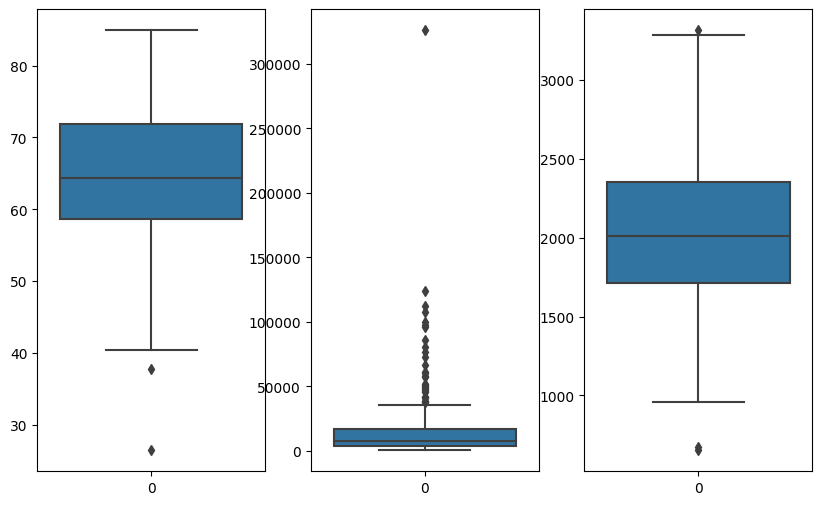

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(10, 6))
sns.boxplot(df['Retirement_Age'], ax=axes[0])
sns.boxplot(df['Debt_Amount'], ax=axes[1])
sns.boxplot(df['Monthly_Savings'], ax=axes[2])
plt.show()

In [30]:
preprocessing = ColumnTransformer(transformers=[
    ('standard_scale', StandardScaler(), ['Retirement_Age', 'Monthly_Savings']),
    ('robust_scale', RobustScaler(), ['Debt_Amount'])
])

In [31]:
main_pipeline = Pipeline(
    steps=[
        ('pre', preprocessing),
        ('model', LogisticRegression())
    ]
) 

In [32]:
main_pipeline.fit(xtrain, ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard_scale', ...), ('robust_scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

### Metrics

#### Confusion metrics

In [33]:
ytrain_pred = main_pipeline.predict(xtrain)
ytest_pred = main_pipeline.predict(xtest)

In [34]:
# train data
cm_train = confusion_matrix(ytrain, ytrain_pred)
print(cm_train)
# test data
cm_test = confusion_matrix(ytest, ytest_pred)
print(cm_test)

[[114   0]
 [  1 122]]
[[33  0]
 [ 0 27]]


In [35]:
total_train_sample = cm_train[:, 0].sum() + cm_train[:, 1].sum()
print(total_train_sample)
total_test_sample = cm_test[:, 0].sum() + cm_train[:, 1].sum()
print(total_test_sample)

237
155


In [36]:
# for train data
accuracy_score(ytrain, ytrain_pred)

0.9957805907172996

### conclusion for train

out of all train samples (237), 99% samples are correctly predicted

In [37]:
# for test data 
accuracy_score(ytest, ytest_pred)

1.0

### conclusion for test

out of all test samples (155), 100% samples are correctly predicted

In [38]:
print(classification_report(ytrain, ytrain_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       114
           1       1.00      0.99      1.00       123

    accuracy                           1.00       237
   macro avg       1.00      1.00      1.00       237
weighted avg       1.00      1.00      1.00       237



In [39]:
print(classification_report(ytest, ytest_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

